In [50]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

In [51]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    print(root)
    for f in files:
        print("  -", f)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/muhammadzackyrachim
/kaggle/input/datasets/muhammadzackyrachim/modelin
  - train.csv
  - test.csv


In [52]:
train_df = pd.read_csv('/kaggle/input/datasets/muhammadzackyrachim/modelin/train.csv')
test_df = pd.read_csv('/kaggle/input/datasets/muhammadzackyrachim/modelin/test.csv')

print(train_df.shape)
print(test_df.shape)
train_df.head()

(3539, 38)
(885, 38)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,dropout_risk
0,1,1,1,9147,1,1,130.0,1,38,37,...,5,5,1,12.000000,0,7.6,2.6,0.32,Dropout,1
1,1,1,1,9853,1,1,129.0,1,38,37,...,6,10,4,11.500000,0,7.6,2.6,0.32,Dropout,1
2,2,39,1,9991,0,1,140.0,1,37,37,...,5,9,2,11.000000,0,12.7,3.7,-1.70,Dropout,1
3,1,17,2,9670,1,1,129.0,1,19,19,...,6,10,5,13.125000,0,10.8,1.4,1.74,Dropout,1
4,1,1,3,9085,1,1,138.0,1,1,1,...,6,12,6,13.833333,0,8.9,1.4,3.51,Graduate,0


In [53]:
target_col = 'dropout_risk'
drop_cols = ['Target', 'dropout_risk']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target_col]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target_col]

In [54]:
numeric_features = X_train.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ]
)

In [55]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    )
}

In [56]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    f1_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='f1')
    roc_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='roc_auc')

    cv_results.append({
        'Model': name,
        'F1 Mean': f1_scores.mean(),
        'F1 Std': f1_scores.std(),
        'ROC-AUC Mean': roc_scores.mean()
    })

cv_df = pd.DataFrame(cv_results).sort_values(by='F1 Mean', ascending=False)
cv_df

,Model,F1 Mean,F1 Std,ROC-AUC Mean
0,Logistic Regression,0.794368,0.021545,0.914768
1,Random Forest,0.790107,0.017608,0.915500


In [57]:
best_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    ))
])

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.8779661016949153
Precision: 0.8410852713178295
Recall   : 0.7640845070422535
F1-score : 0.8007380073800738
ROC-AUC  : 0.9293313960300907

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       601
           1       0.84      0.76      0.80       284

    accuracy                           0.88       885
   macro avg       0.87      0.85      0.86       885
weighted avg       0.88      0.88      0.88       885



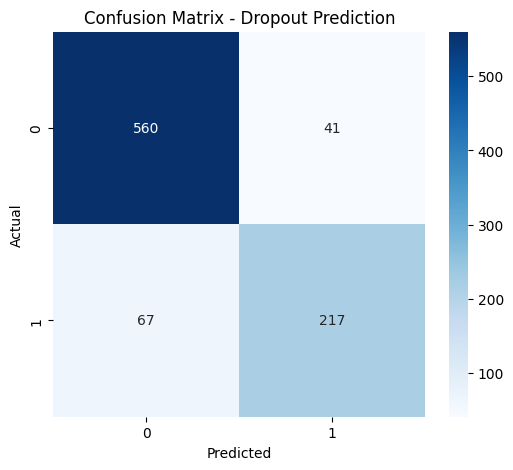

In [58]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Dropout Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [59]:
rf_model = best_model.named_steps['model']
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

importance_df.head(15)

,feature,importance
30,Curricular units 2nd sem (approved),0.203079
31,Curricular units 2nd sem (grade),0.118919
24,Curricular units 1st sem (approved),0.102691
25,Curricular units 1st sem (grade),0.073666
16,Tuition fees up to date,0.068372
19,Age at enrollment,0.041881
29,Curricular units 2nd sem (evaluations),0.032260
3,Course,0.025856
12,Admission grade,0.025706
6,Previous qualification (grade),0.024988


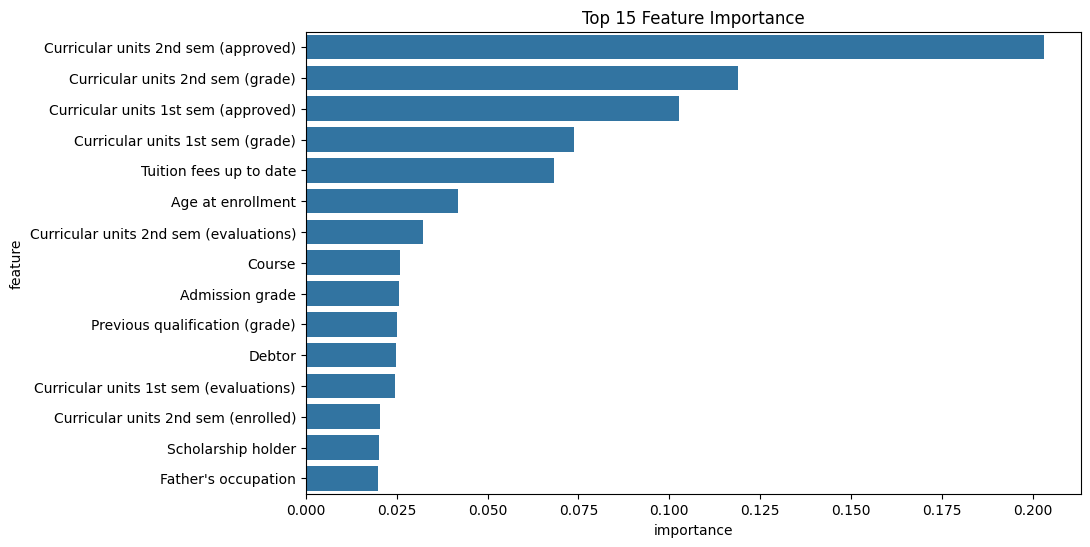

In [60]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(15), x='importance', y='feature')
plt.title('Top 15 Feature Importance')
plt.show()

In [61]:
os.makedirs('/kaggle/working/models', exist_ok=True)
joblib.dump(best_model, '/kaggle/working/models/best_model.pkl')
print("Model saved!")

Model saved!
